In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('../data/processed/cleaned_shots.csv')

df.head()

,minute,second,period,team_name,player_name,position_name,x,y,end_x,end_y,...,play_pattern_name,under_pressure,shot_first_time,shot_one_on_one,shot_open_goal,shot_deflected,shot_statsbomb_xg,outcome_name,season_name,goal
0,0,18,1,Switzerland,Granit Xhaka,Left Defensive Midfield,96.0,38.8,108.2,38.5,...,From Kick Off,False,True,False,False,False,0.036566,Blocked,2022,0
1,0,22,1,Switzerland,Breel-Donald Embolo,Center Forward,113.1,40.7,114.8,40.6,...,From Kick Off,False,True,False,False,False,0.353289,Saved,2022,0
2,0,23,1,Switzerland,Granit Xhaka,Left Defensive Midfield,103.8,41.9,115.5,39.1,...,From Kick Off,False,True,False,False,False,0.069527,Saved,2022,0
3,4,35,1,Serbia,Nikola Milenković,Right Center Back,112.2,36.8,120.0,35.3,...,From Corner,False,False,False,False,False,0.081609,Off T,2022,0
4,10,5,1,Serbia,Andrija Živković,Right Wing Back,97.8,51.5,120.0,36.1,...,Regular Play,False,False,False,False,False,0.030002,Post,2022,0


In [12]:
df['shot_distance']= np.sqrt(
    (120 - df['x'])**2 + (40 - df['y'])**2
)

df[['x','y','shot_distance']].head()

,x,y,shot_distance
0,96.0,38.8,24.029981
1,113.1,40.7,6.935416
2,103.8,41.9,16.311039
3,112.2,36.8,8.430896
4,97.8,51.5,25.001800


In [13]:
goal_width = 7.32

left_post_y = 40 - (goal_width/2)
right_post_y = 40 + (goal_width/2)

df['angle'] = np.arctan2(
    right_post_y - df['y'],
    120 - df['x']
) - np.arctan2(
    left_post_y - df['y'],
    120 - df['x']
)
df['angle'] = np.abs(df['angle'])
df[['x','y','angle']].head()

,x,y,angle
0,96.0,38.8,0.301942
1,113.1,40.7,0.968776
2,103.8,41.9,0.438830
3,112.2,36.8,0.780272
4,97.8,51.5,0.259664


In [14]:
df['centrality'] = np.abs(40 -df['y'])

df[['y','centrality']].head()

,y,centrality
0,38.8,1.2
1,40.7,0.7
2,41.9,1.9
3,36.8,3.2
4,51.5,11.5


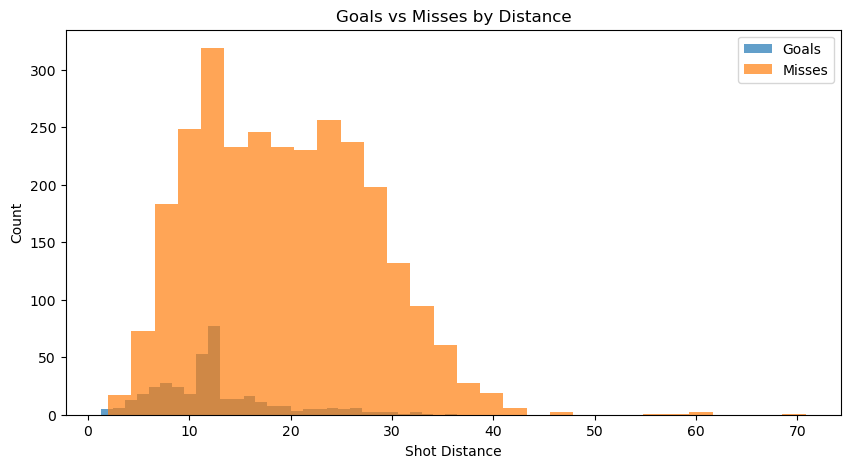

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    df[df['goal'] == 1]['shot_distance'],
    bins=30,
    alpha=0.7,
    label='Goals'
)

plt.hist(
    df[df['goal'] == 0]['shot_distance'],
    bins=30,
    alpha=0.7,
    label='Misses'
)

plt.xlabel("Shot Distance")
plt.ylabel("Count")
plt.title("Goals vs Misses by Distance")

plt.legend()

plt.show()

In [17]:
features = [
    'minute',
    'period',
    'x',
    'y',
    'shot_distance',
    'angle',
    'centrality',
    'body_part_name',
    'technique_name',
    'play_pattern_name',
    'under_pressure',
    'shot_first_time',
    'shot_one_on_one',
    'shot_open_goal',
    'shot_deflected'
]

X = df[features]

y = df['goal']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(2560, 15)
(640, 15)


In [19]:
df[['shot_distance', 'angle', 'centrality']].head()

,shot_distance,angle,centrality
0,24.029981,0.301942,1.2
1,6.935416,0.968776,0.7
2,16.311039,0.438830,1.9
3,8.430896,0.780272,3.2
4,25.001800,0.259664,11.5


In [20]:
df.to_csv(
    "../data/processed/feature_engineered_shots.csv",
    index=False
)